In [1]:

# Oasis Infobyte - Data Analytics Internship
# Task 1: EDA on Retail Sales Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")
print("Ready to start Retail Sales Data Analysis.")


All libraries imported successfully!
Ready to start Retail Sales Data Analysis.


In [2]:

import pandas as pd

df = pd.read_csv("retail_sales_dataset.csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()



Dataset loaded successfully!
Dataset shape: (1000, 9)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [3]:

print("Column Names:")
print(df.columns.tolist())


print("\nDataset Information:")
df.info()


print("\nMissing Values:")
print(df.isnull().sum())


print("\nStatistical Summary:")
display(df.describe())


Column Names:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price 

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [7]:

# Convert Date column into datetime format
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Extract month and year
df["YearMonth"] = df["Date"].dt.to_period("M")

print("Date conversion completed!")
print(df[["Date", "YearMonth", "Total Amount"]].head())


Date conversion completed!
        Date YearMonth  Total Amount
0 2023-11-24   2023-11           150
1 2023-02-27   2023-02          1000
2 2023-01-13   2023-01            30
3 2023-05-21   2023-05           500
4 2023-05-06   2023-05           100


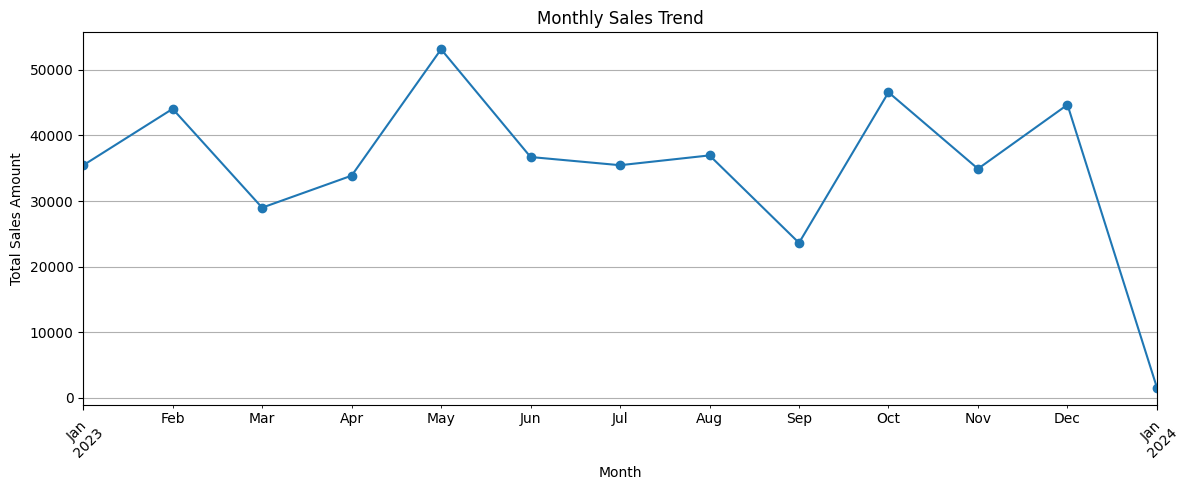

In [8]:

# Calculate total sales for each month
monthly_sales = df.groupby("YearMonth")["Total Amount"].sum()

# Plot monthly sales
plt.figure(figsize=(12, 5))
monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()



### Observation: Monthly Sales Trend

The line graph shows how total sales change from month to month. Some months have higher sales, while others have lower sales. The business can use this information to plan promotions and manage stock.


In [9]:

# Sales by Product Category

category_sales = df.groupby("Product Category")["Total Amount"].sum()

print("Total Sales by Product Category:")
print(category_sales.sort_values(ascending=False))


Total Sales by Product Category:
Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


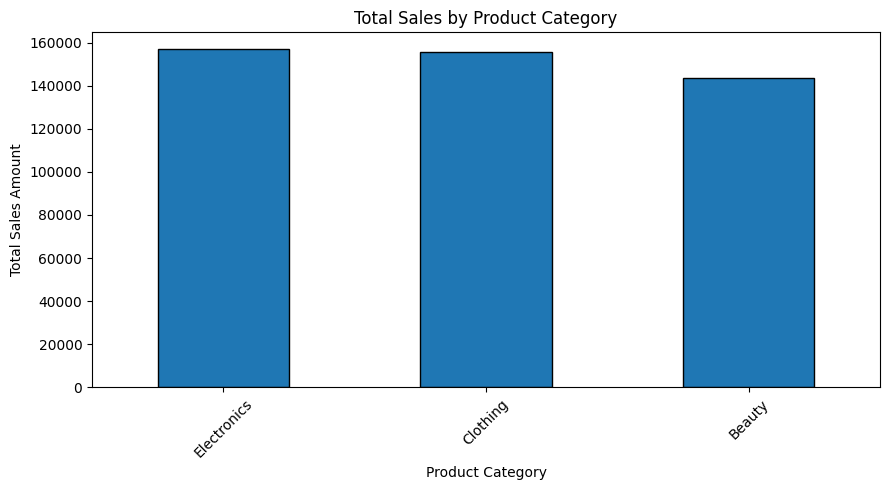

In [10]:

plt.figure(figsize=(9, 5))

category_sales.sort_values(ascending=False).plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



### Observation: Sales by Product Category

The bar chart compares total sales across different product categories. It helps identify which categories generate more revenue and which categories may need better marketing or promotion.


In [11]:

# Gender Analysis

gender_count = df["Gender"].value_counts()

print("Number of Customers by Gender:")
print(gender_count)




Number of Customers by Gender:
Gender
Female    510
Male      490
Name: count, dtype: int64


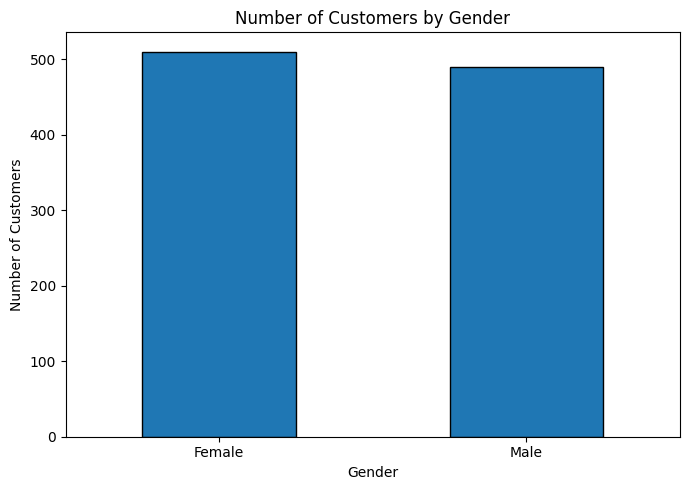

In [12]:

plt.figure(figsize=(7, 5))

gender_count.plot(kind="bar", edgecolor="black")

plt.title("Number of Customers by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Total Sales by Gender:
Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64


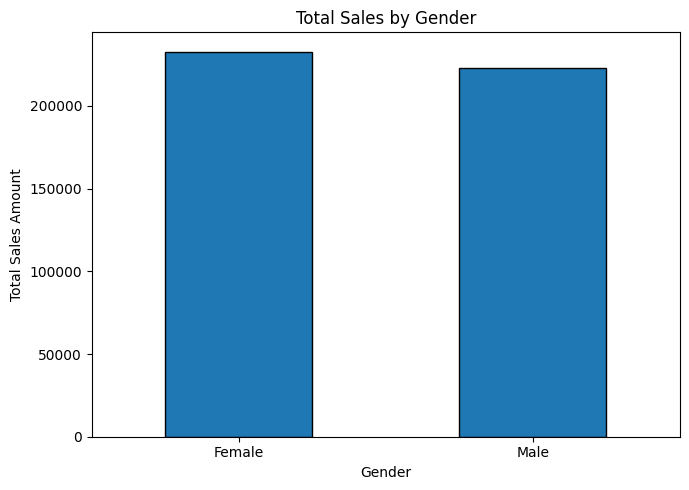

In [13]:

gender_sales = df.groupby("Gender")["Total Amount"].sum()

print("Total Sales by Gender:")
print(gender_sales)

gender_sales.plot(kind="bar", figsize=(7, 5), edgecolor="black")
plt.title("Total Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



### Observation: Gender Analysis

The gender analysis shows the number of customers and total sales for each gender. Comparing these results helps the business understand its customer distribution and identify opportunities to improve marketing strategies.


In [14]:

# Create Age Groups

bins = [17, 25, 35, 45, 55, 65, float("inf")]
labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65",
    "66+"
]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

age_group_count = df["Age Group"].value_counts().sort_index()

print("Number of Customers by Age Group:")
print(age_group_count)


Number of Customers by Age Group:
Age Group
18-25    169
26-35    205
36-45    202
46-55    229
56-65    195
66+        0
Name: count, dtype: int64


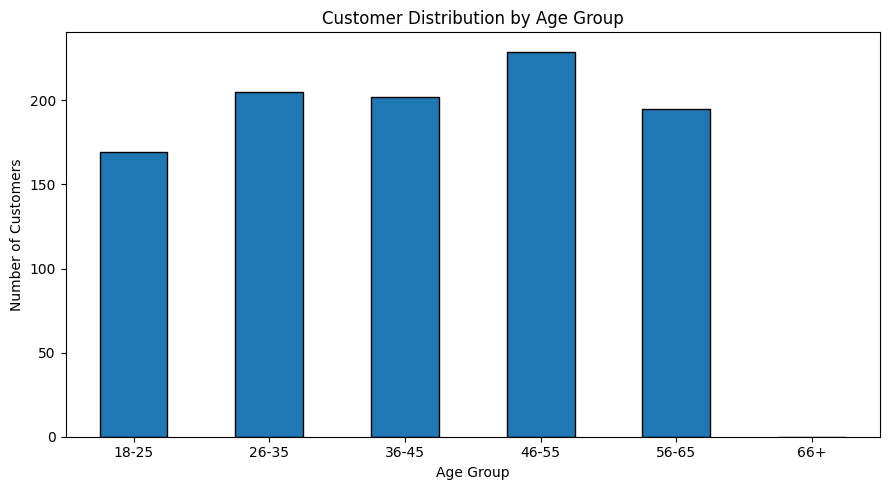

In [15]:

plt.figure(figsize=(9, 5))

age_group_count.plot(kind="bar", edgecolor="black")

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


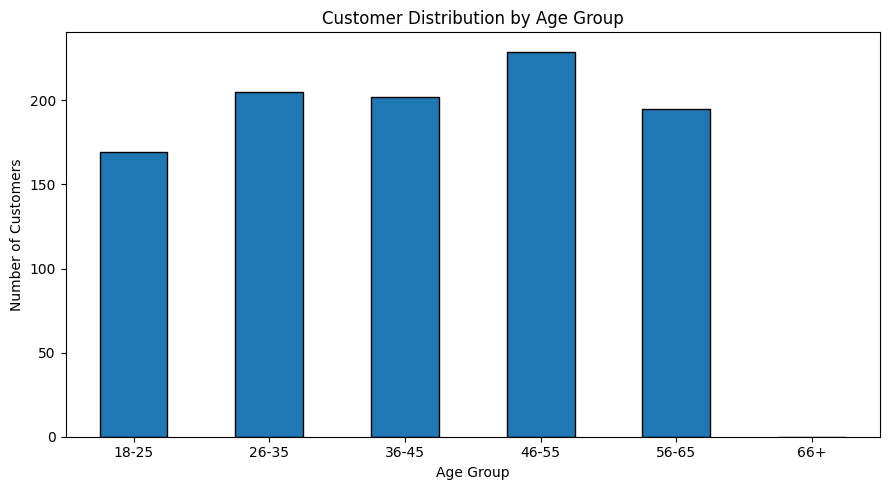

In [16]:

plt.figure(figsize=(9, 5))

age_group_count.plot(kind="bar", edgecolor="black")

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Total Sales by Age Group:
Age Group
18-25     84550
26-35     98480
36-45     91870
46-55    100690
56-65     80410
66+           0
Name: Total Amount, dtype: int64


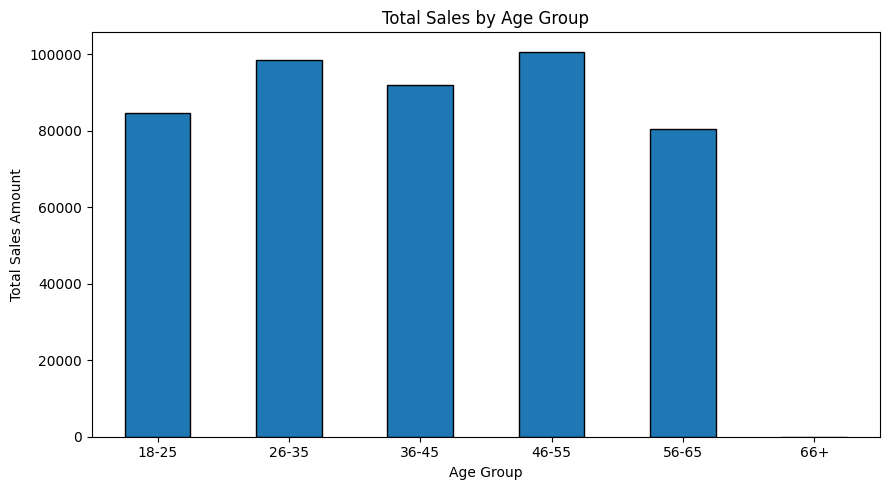

In [17]:

age_group_sales = (
    df.groupby("Age Group", observed=False)["Total Amount"]
    .sum()
)

print("Total Sales by Age Group:")
print(age_group_sales)

age_group_sales.plot(
    kind="bar",
    figsize=(9, 5),
    edgecolor="black"
)

plt.title("Total Sales by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



### Observation: Age Group Analysis

The age group analysis shows how customers are distributed across different age ranges. Comparing total sales by age group helps identify important customer segments and plan suitable marketing campaigns.


In [18]:

gender_count = df["Gender"].value_counts()

print(gender_count)


Gender
Female    510
Male      490
Name: count, dtype: int64


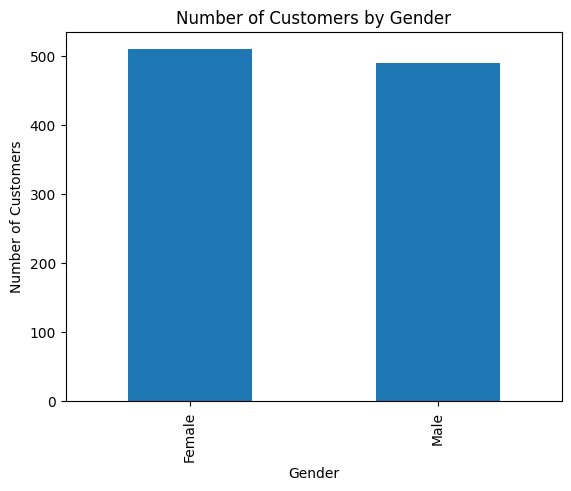

In [19]:

gender_count.plot(kind="bar")

plt.title("Number of Customers by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()


In [20]:

# Create Age Groups

bins = [17, 25, 35, 45, 55, 65, float("inf")]
labels = ["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

age_group_count = df["Age Group"].value_counts().sort_index()

print("Number of Customers by Age Group:")
print(age_group_count)


Number of Customers by Age Group:
Age Group
18-25    169
26-35    205
36-45    202
46-55    229
56-65    195
66+        0
Name: count, dtype: int64


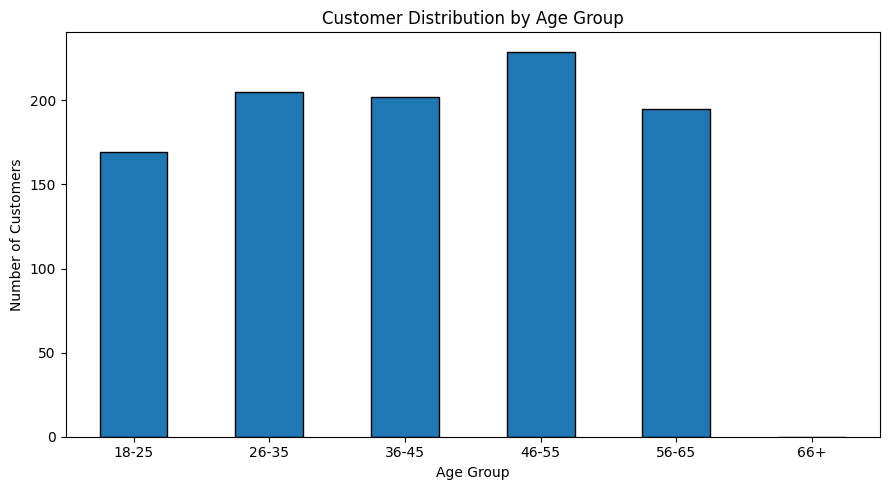

In [21]:

plt.figure(figsize=(9, 5))

age_group_count.plot(kind="bar", edgecolor="black")

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [22]:

age_group_sales = df.groupby(
    "Age Group",
    observed=False
)["Total Amount"].sum()

print("Total Sales by Age Group:")
print(age_group_sales)


Total Sales by Age Group:
Age Group
18-25     84550
26-35     98480
36-45     91870
46-55    100690
56-65     80410
66+           0
Name: Total Amount, dtype: int64


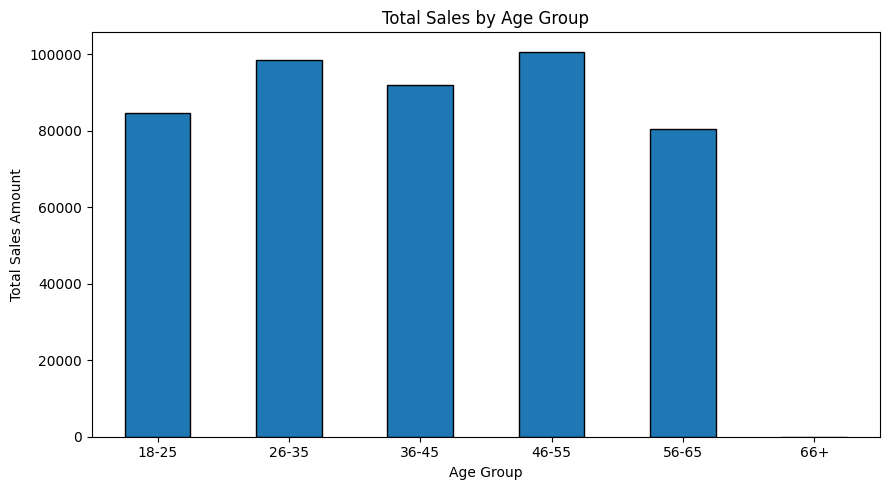

In [23]:

age_group_sales.plot(
    kind="bar",
    figsize=(9, 5),
    edgecolor="black"
)

plt.title("Total Sales by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [24]:

print("Columns in our dataset:")
print(df.columns.tolist())


Columns in our dataset:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount', 'YearMonth', 'Age Group']


In [25]:

# Total Quantity Sold by Product Category

category_quantity = df.groupby(
    "Product Category"
)["Quantity"].sum().sort_values(ascending=False)

print("Quantity Sold by Product Category:")
print(category_quantity)


Quantity Sold by Product Category:
Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64


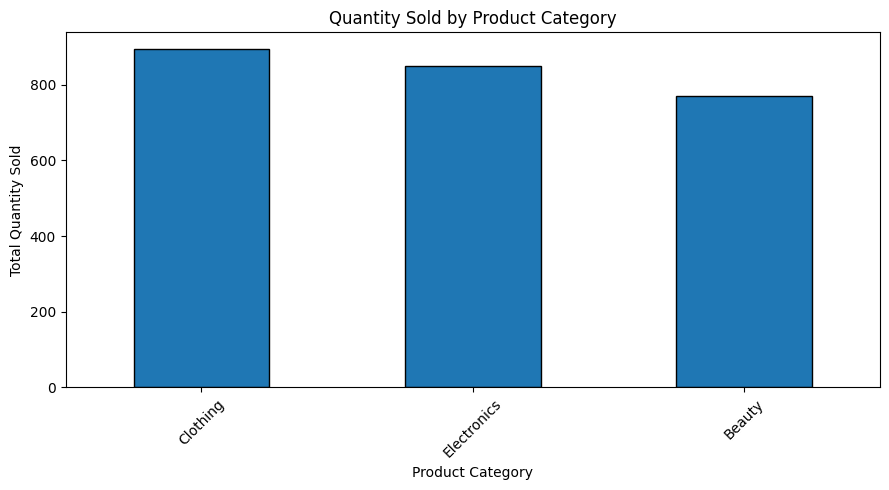

In [26]:

category_quantity.plot(
    kind="bar",
    figsize=(9, 5),
    edgecolor="black"
)

plt.title("Quantity Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



### Observation: Quantity Sold by Product Category

The bar chart compares the total quantity sold across product categories. It helps identify which categories have higher product demand and supports inventory planning and sales strategies.


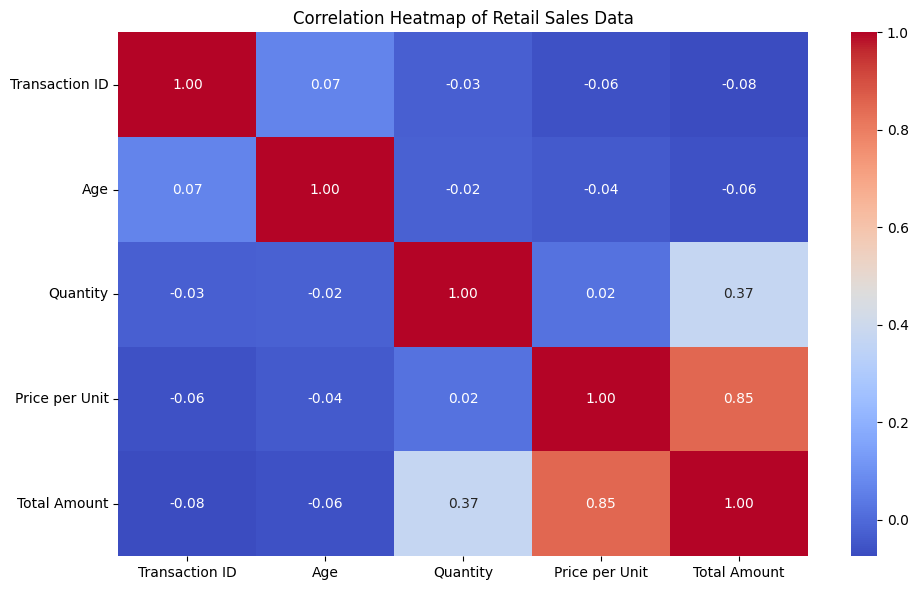

In [27]:

# Correlation Heatmap

numeric_df = df.select_dtypes(include="number")

correlation = numeric_df.corr()

plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Retail Sales Data")
plt.tight_layout()
plt.show()



### Observation: Correlation Heatmap

The correlation heatmap shows the relationships between numerical variables in the retail sales dataset. Values closer to 1 indicate a stronger positive linear relationship, values closer to -1 indicate a stronger negative linear relationship, and values near 0 indicate a weaker linear relationship.


In [29]:

print(df.columns.tolist())



['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount', 'YearMonth', 'Age Group']


In [31]:

# Average Price per Unit by Product Category

avg_price = df.groupby("Product Category")["Price per Unit"].mean()

print("Average Price per Unit by Category:")
print(avg_price)


Average Price per Unit by Category:
Product Category
Beauty         184.055375
Clothing       174.287749
Electronics    181.900585
Name: Price per Unit, dtype: float64



avg_price.plot(
    kind="bar",
    figsize=(8, 5),
    edgecolor="black"
)

plt.title("Average Price per Unit by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Price per Unit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




### Observation: Average Price per Unit

The bar chart compares the average price per unit across product categories. It helps the business understand price differences between categories and make better pricing and product planning decisions.



# Conclusion

Exploratory Data Analysis (EDA) was performed on the retail sales dataset using Python, Pandas, Matplotlib, and Seaborn.

The analysis explored monthly sales trends, product category performance, customer gender, age groups, quantity sold, and average price per unit. Visualizations were used to understand patterns in the data and compare sales performance across different customer segments and product categories.

This analysis can help the business make data-driven decisions related to marketing, inventory management, and sales planning.



# Business Recommendations

1. **Improve Marketing Strategies:** Use customer gender and age-group analysis to design targeted marketing campaigns for different customer segments.

2. **Optimize Inventory:** Monitor quantity sold across product categories and maintain sufficient stock for categories with higher demand.

3. **Plan Sales Activities:** Track monthly sales trends and use promotions during lower-sales periods to encourage more purchases.

